In [ ]:
from pathlib import Path
import kagglehub

# Download latest version
path = kagglehub.dataset_download("changheonkim/iam-trocr")
path = Path(path)/"IAM"
print("Path to dataset files:", path)

gt_file = path / "gt_test.txt"

labels_dict = {}

with open(gt_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")  # usa TAB
        if len(parts) == 2:
            image_name, text = parts
            image_id = Path(image_name).stem
            labels_dict[image_id] = text

print("Total labels:", len(labels_dict))
print("Exemplo chave:", list(labels_dict.keys())[:5])

Using Colab cache for faster access to the 'iam-trocr' dataset.
Path to dataset files: /kaggle/input/iam-trocr/IAM
Total labels: 2915
Exemplo chave: ['c04-110-00', 'c04-110-01', 'c04-110-02', 'c04-110-03', 'c04-116-00']


In [ ]:
import os

# Assuming 'path' variable holds the base directory from kagglehub.dataset_download
# If not, please replace 'path' with the correct directory string, e.g., '/content/IAM'
if 'path' in globals():
    print(f"Listing directories in: {path}")
    # Use a shell command to list only directories recursively, and sort them
    !ls {path/"image"}

Listing directories in: /kaggle/input/iam-trocr/IAM
c04-110-00.jpg	e06-070-02.jpg	 g07-000b-00.jpg  n02-157-05.jpg
c04-110-01.jpg	e06-070-03.jpg	 g07-000b-01.jpg  n02-157-06.jpg
c04-110-02.jpg	e06-070-04.jpg	 g07-000b-02.jpg  n02-157-07.jpg
c04-110-03.jpg	e06-070-05.jpg	 g07-000b-03.jpg  n02-157-08.jpg
c04-116-00.jpg	e06-070-06.jpg	 g07-000b-04.jpg  n03-038-00.jpg
c04-116-01.jpg	e06-070-07.jpg	 g07-000b-05.jpg  n03-038-01.jpg
c04-116-02.jpg	e06-070-08.jpg	 g07-000b-06.jpg  n03-038-02.jpg
c04-116-03.jpg	e06-070-09.jpg	 g07-000b-07.jpg  n03-038-03.jpg
c04-134-00.jpg	f04-032-00.jpg	 g07-000b-08.jpg  n03-038-04.jpg
c04-134-01.jpg	f04-032-01.jpg	 g07-000b-09.jpg  n03-038-05.jpg
c04-134-02.jpg	f04-032-02.jpg	 g07-079a-00.jpg  n03-038-06.jpg
c04-134-03.jpg	f04-032-03.jpg	 g07-079a-01.jpg  n03-064-00.jpg
c04-134-04.jpg	f04-032-04.jpg	 g07-079a-02.jpg  n03-064-01.jpg
c04-134-05.jpg	f04-032-05.jpg	 g07-079a-03.jpg  n03-064-02.jpg
c04-134-06.jpg	f04-032-06.jpg	 g07-079a-04.jpg  n03-064-03.jpg
c04

In [ ]:
import glob

# Assuming 'path' is defined and points to the base directory of the dataset
# The images are located in the 'image' subdirectory relative to 'path'
image_directory = path / "image"

# Use glob to find all .jpg files in the image directory
image_paths = sorted(glob.glob(str(image_directory / "*.jpg")))

print(f"Found {len(image_paths)} images in the dataset.")
print("First 5 image paths:")
for i, img_path in enumerate(image_paths[:5]):
    print(f"  {i+1}: {img_path}")

Found 2915 images in the dataset.
First 5 image paths:
  1: /kaggle/input/iam-trocr/IAM/image/c04-110-00.jpg
  2: /kaggle/input/iam-trocr/IAM/image/c04-110-01.jpg
  3: /kaggle/input/iam-trocr/IAM/image/c04-110-02.jpg
  4: /kaggle/input/iam-trocr/IAM/image/c04-110-03.jpg
  5: /kaggle/input/iam-trocr/IAM/image/c04-116-00.jpg


In [ ]:
from transformers import DonutProcessor, VisionEncoderDecoderModel
import torch

processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base")
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base")

processor.image_processor.size = {"height": 512, "width": 512}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
The image processor of type `DonutImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/484 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie decoder.model.decoder.embed_tokens.weight to decoder.lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


VisionEncoderDecoderModel(
  (encoder): DonutSwinModel(
    (embeddings): DonutSwinEmbeddings(
      (patch_embeddings): DonutSwinPatchEmbeddings(
        (projection): Conv2d(3, 128, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): DonutSwinEncoder(
      (layers): ModuleList(
        (0): DonutSwinStage(
          (blocks): ModuleList(
            (0): DonutSwinLayer(
              (layernorm_before): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
              (attention): DonutSwinAttention(
                (self): DonutSwinSelfAttention(
                  (query): Linear(in_features=128, out_features=128, bias=True)
                  (key): Linear(in_features=128, out_features=128, bias=True)
                  (value): Linear(in_features=128, out_features=128, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )

In [ ]:
filtered_image_paths = [
    img_path for img_path in image_paths
    if Path(img_path).stem in labels_dict
]

print("Imagens com label:", len(filtered_image_paths))

Imagens com label: 2915


In [ ]:
from pathlib import Path
import torch
from torch.utils.data import Dataset
from PIL import Image

class IAMDonutDataset(Dataset):
    def __init__(self, image_paths, labels_dict, processor):
        self.image_paths = image_paths
        self.labels_dict = labels_dict
        self.processor = processor

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")

        file_name = Path(img_path).stem
        text = self.labels_dict[file_name]

        pixel_values = self.processor(
            image,
            return_tensors="pt"
        ).pixel_values.squeeze()

        labels = self.processor.tokenizer(
            text,
            add_special_tokens=True,
            return_tensors="pt"
        ).input_ids.squeeze()

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }


iam_dataset = IAMDonutDataset(
    image_paths=image_paths,
    labels_dict=labels_dict,
    processor=processor
)

print("Número de amostras:", len(iam_dataset))

sample = iam_dataset[0]
print("Shape pixel_values:", sample["pixel_values"].shape)
print("Shape labels:", sample["labels"].shape)

Número de amostras: 2915
Shape pixel_values: torch.Size([3, 512, 512])
Shape labels: torch.Size([27])


In [ ]:
def predict(image):
    pixel_values = processor(image, return_tensors="pt").pixel_values.to(device)

    task_prompt = "<s>"

    decoder_input_ids = processor.tokenizer(
        task_prompt,
        add_special_tokens=False,
        return_tensors="pt"
    ).input_ids.to(device)

    with torch.no_grad():
        outputs = model.generate(
            pixel_values,
            decoder_input_ids=decoder_input_ids,
            max_length=128,
            early_stopping=True
        )

    prediction = processor.batch_decode(outputs, skip_special_tokens=True)[0]
    return prediction

In [ ]:
gt_file = path / "gt_test.txt"

labels_dict = {}

with open(gt_file, "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split("\t")  # ← usar TAB

        if len(parts) == 2:
            image_name, text = parts

            image_id = Path(image_name).stem  # remove .jpg
            labels_dict[image_id] = text

print("Total labels:", len(labels_dict))
print("Primeiras 5 chaves:", list(labels_dict.keys())[:5])

Total labels: 2915
Primeiras 5 chaves: ['c04-110-00', 'c04-110-01', 'c04-110-02', 'c04-110-03', 'c04-116-00']


In [ ]:
train_dataset = IAMDonutDataset(
    image_paths=filtered_image_paths,
    labels_dict=labels_dict,
    processor=processor
)

In [ ]:
from sklearn.model_selection import train_test_split

train_paths, val_paths = train_test_split(
    filtered_image_paths,
    test_size=0.1,
    random_state=42
)

train_dataset = IAMDonutDataset(train_paths, labels_dict, processor)
val_dataset = IAMDonutDataset(val_paths, labels_dict, processor)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))

Train: 2623
Val: 292


In [ ]:
model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
model.config.pad_token_id = processor.tokenizer.pad_token_id
model.config.eos_token_id = processor.tokenizer.eos_token_id
model.config.vocab_size = model.config.decoder.vocab_size

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments

training_args = Seq2SeqTrainingArguments(
    output_dir="./donut-iam",
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=2,
    num_train_epochs=2,
    learning_rate=2e-5,
    logging_steps=100,
    save_strategy="steps",
    save_steps=300,
    predict_with_generate=True,
    fp16=torch.cuda.is_available(),
    save_total_limit=3
)

In [ ]:
from dataclasses import dataclass
from typing import Any, Dict, List
import torch

@dataclass
class DonutDataCollator:
    processor: Any
    model: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        pixel_values = torch.stack([f["pixel_values"] for f in features])

        labels = [f["labels"] for f in features]
        labels = self.processor.tokenizer.pad(
            {"input_ids": labels},
            padding=True,
            return_tensors="pt"
        )["input_ids"]

        # Ignorar padding na loss
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels
        }

In [ ]:
data_collator = DonutDataCollator(processor, model)

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator
)

In [ ]:
torch.cuda.empty_cache()

trainer.train()

Step,Training Loss
100,3.195444
200,1.418690
300,1.319216
400,0.944931
500,0.938427
600,0.972301
700,0.914730
800,0.879298
900,0.851862
1000,0.831577


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2624, training_loss=0.7443615979537731, metrics={'train_runtime': 2603.0428, 'train_samples_per_second': 2.015, 'train_steps_per_second': 1.008, 'total_flos': 4.957606283034231e+18, 'train_loss': 0.7443615979537731, 'epoch': 2.0})

In [ ]:
!pip install jiwer

In [ ]:
from jiwer import wer, cer
from tqdm import tqdm
import torch

model.eval()

def evaluate_model_full(dataset):
    total_cer = 0
    total_wer = 0
    n = len(dataset)

    for i in tqdm(range(n)):
        sample = dataset[i]

        # Adiciona batch dimension e manda pra GPU
        pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = model.generate(pixel_values, max_length=128)

        # Decodifica a previsão
        prediction = processor.batch_decode(outputs, skip_special_tokens=True)[0]

        # Decodifica o ground truth
        ground_truth = processor.tokenizer.decode(
            sample["labels"],
            skip_special_tokens=True
        )

        total_cer += cer(ground_truth, prediction)
        total_wer += wer(ground_truth, prediction)

    print("\nResultados finais para todas as imagens:")
    print("CER:", total_cer / n)
    print("WER:", total_wer / n)

# Rodar avaliação para todas as imagens do val_dataset
evaluate_model_full(val_dataset)

100%|██████████| 292/292 [01:39<00:00,  2.93it/s]


Resultados finais para todas as imagens:
CER: 0.06493366575795172
WER: 0.17193278395433928


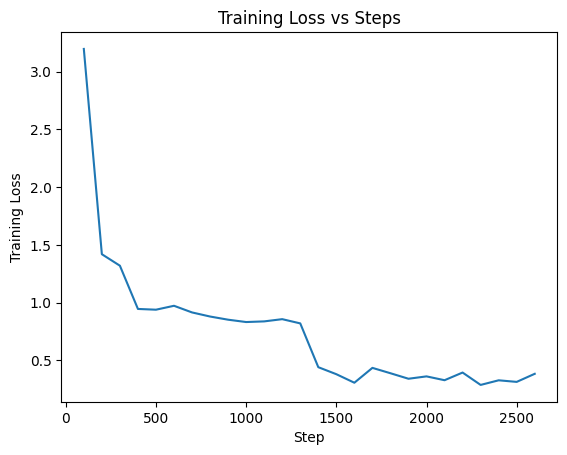

In [ ]:
import matplotlib.pyplot as plt

logs = trainer.state.log_history

steps = []
losses = []

for log in logs:
    if "loss" in log:
        steps.append(log["step"])
        losses.append(log["loss"])

# plot
plt.figure()
plt.plot(steps, losses)
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Steps")
plt.show()